age   -1.444295e-18
sex    2.543215e-18
bmi   -2.255925e-16
bp    -4.854086e-17
s1    -1.428596e-17
s2     3.898811e-17
s3    -6.028360e-18
s4    -1.788100e-17
s5     9.168131e-17
s6     1.351770e-17
dtype: float64
age    0.047619
sex    0.047619
bmi    0.047619
bp     0.047619
s1     0.047619
s2     0.047619
s3     0.047619
s4     0.047619
s5     0.047619
s6     0.047619
dtype: float64
age    0.110727
sex    0.050680
bmi    0.170555
bp     0.132044
s1     0.153914
s2     0.198788
s3     0.181179
s4     0.185234
s5     0.133597
s6     0.135612
dtype: float64
age   -0.107226
sex   -0.044642
bmi   -0.090275
bp    -0.112399
s1    -0.126781
s2    -0.115613
s3    -0.102307
s4    -0.076395
s5    -0.126097
s6    -0.137767
dtype: float64


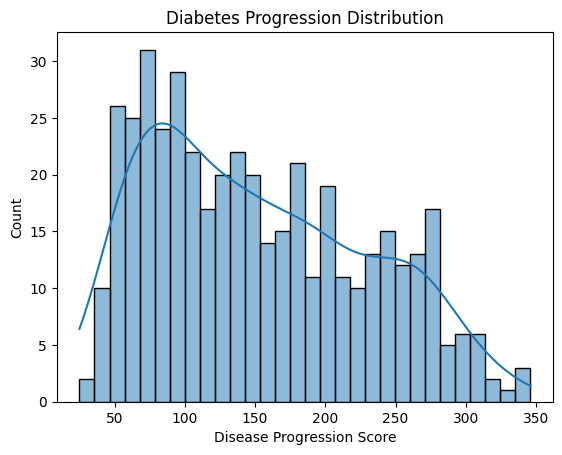

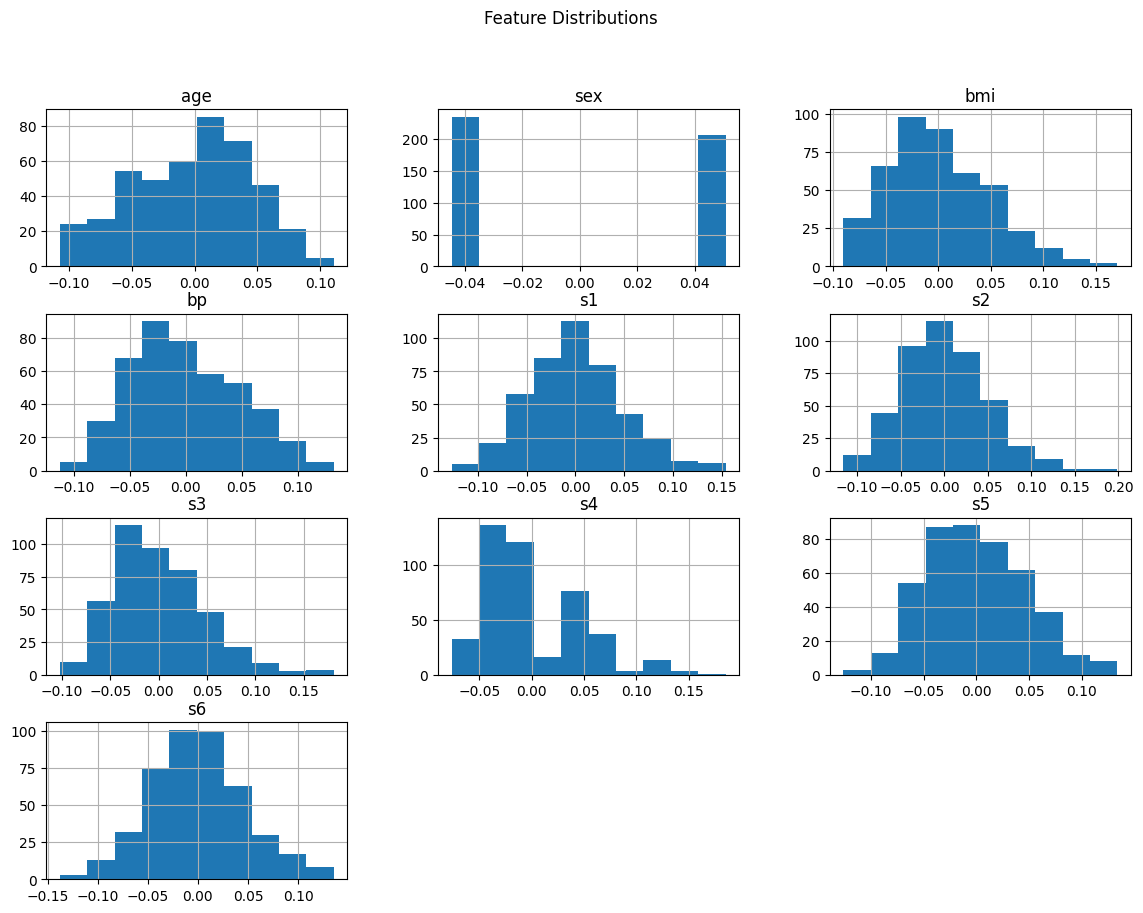

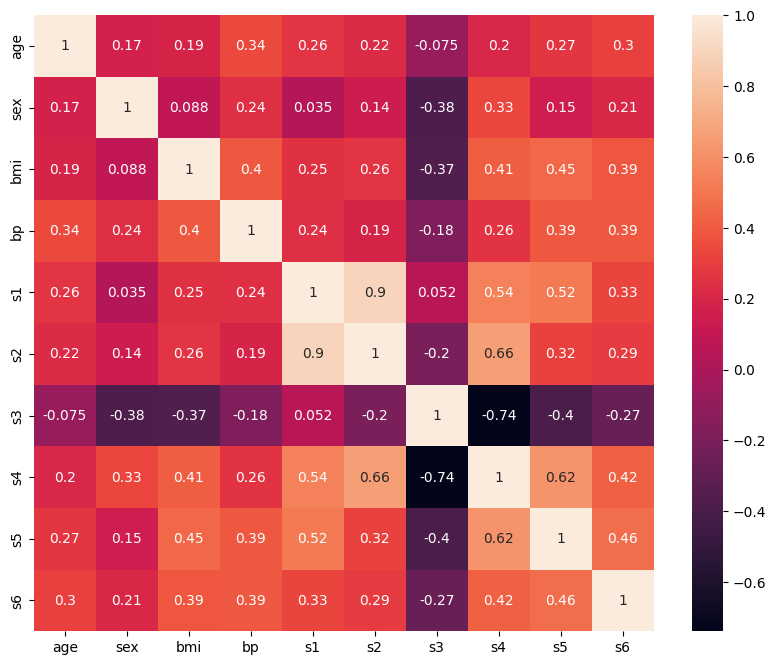

XGBoost MAE: 46.39
XGBoost R2: 0.37
XGBoost RMSE: 57.89
RandomForest MAE: 44.05
RandomForest R2: 0.44
RandomForest RMSE: 54.33


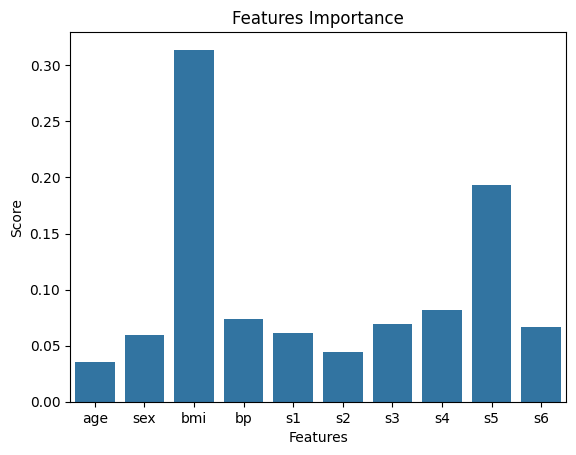

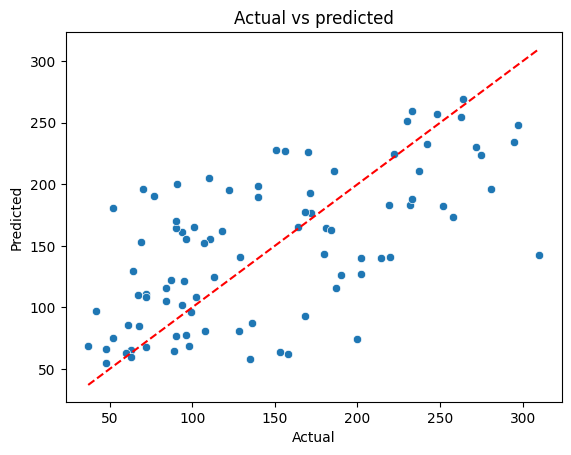

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
from xgboost import XGBRegressor
X,y=load_diabetes(return_X_y=True)
data=load_diabetes()
col=data.feature_names
df=pd.DataFrame(X,columns=col)
#print(pd.isnull(df).sum()) #check whether there are missing data or not
print(df.mean())
print(df.std())
print(df.max())
print(df.min())
sns.histplot(y,bins=30,kde=True)
plt.xlabel("Disease Progression Score")
plt.title("Diabetes Progression Distribution")
df.hist(figsize=(14, 10))
plt.suptitle("Feature Distributions")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(),annot=True)
plt.savefig("heatmap.png")
plt.show()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
xg=XGBRegressor()
xg.fit(X_train,y_train)
xgp=xg.predict(X_test)
mae_xg=mean_absolute_error(y_test,xgp)
r2_xg=r2_score(y_test,xgp)
rmse_xg=root_mean_squared_error(y_test,xgp)
print(f"XGBoost MAE: {mae_xg:.2f}")
print(f"XGBoost R2: {r2_xg:.2f}")
print(f"XGBoost RMSE: {rmse_xg:.2f}")
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
rfp=rf.predict(X_test)
mae_rf=mean_absolute_error(y_test,rfp)
r2_rf=r2_score(y_test,rfp)
rmse_rf=root_mean_squared_error(y_test,rfp)
print(f"RandomForest MAE: {mae_rf:.2f}")
print(f"RandomForest R2: {r2_rf:.2f}")
print(f"RandomForest RMSE: {rmse_rf:.2f}")
sns.barplot(x=col, y=xg.feature_importances_)
plt.title("Features Importance")
plt.xlabel("Features")
plt.ylabel("Score")
plt.show()
sns.scatterplot(x=y_test,y=xgp)
plt.title("Actual vs predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"--r")
plt.show()
